In [1]:
# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text

warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

# Make new db file for human 
gtf_file = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode.v45.primary_assembly.annotation.gtf"
db_file  = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencodev45.db"

#gffutils.create_db(gtf_file, dbfn=db_file, 
#                   force=True, keep_order=True, 
#                   disable_infer_transcripts=True, 
#                   disable_infer_genes=True)

# Load the database
db_human = gffutils.FeatureDB(db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results"

GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_scvi_model_latent_20_2025-08-04.h5ad"

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/TMS_atse_file_unanno_also_2025-07-31_08-10-26.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load splicing data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
print(f"Done reading the ge_adata with scVI...")

# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)

if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# Assign gene RBP vs Aging gene status       
ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["gene_name"])
ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_human)
aging_genes = aging_genes_human
rbps = rbps["gene_name"]

print(f"Done getting RBPs and Aging genes...")

Done reading the ge_adata with scVI...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Done getting RBPs and Aging genes...


In [3]:
# Main parameters to change
MODEL_TRAIN_DATE = "2025-07-31"
MODEL_ANALYSIS_DATE = "2025-08-01"
PARAM_ID = 1

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"

# Main data files from downstream analysis of model 
SPLICE_ADATA_PATH = f"{DATA_DIR}/splice_adata_PHI_psi_var_obs.h5ad"
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
PERPLEXITY_PATH =  f"{DATA_DIR}/cell_metadata_with_perplexity_param_id_{PARAM_ID}.csv.gz"
DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

print(f"Loading data for param_id {PARAM_ID} from {MODEL_TRAIN_DATE}")
print(f"Data directory: {DATA_DIR}")

# Load main datasets
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

pi = np.load(PI_VALUES_PATH)
diff_spl = pd.read_csv(DIFF_SPL_PATH)
perplexity_df = pd.read_csv(PERPLEXITY_PATH)
perplexity_df = perplexity_df.set_index("cell_id")
leaflet_model = load_model(MODEL_PATH)

splice_adata.obs_names = splice_adata.obs["cell_id"]
assert all(splice_adata.obs_names == perplexity_df.index), "Cell IDs in filtered_splice_adata and perplexity_df do not match or are not in the same order"
splice_adata.obs["perplexity"] = perplexity_df["perplexity"]

print(f"Loaded splice_adata: {splice_adata.shape}")
print(f"Loaded PI values: {pi.shape}")
print(f"Loaded diff_spl: {diff_spl.shape}")

MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"
leaflet_model = load_model(MODEL_PATH)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Loading data for param_id 1 from 2025-07-31
Data directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/data
Loading model to device: cpu
Loaded splice_adata: (75323, 19486)
Loaded PI values: (20,)
Loaded diff_spl: (30894, 49)
Loading model to device: cpu
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs


In [4]:
splice_adata.var["RBP_gene"].value_counts()

RBP_gene
False    18353
True      1133
Name: count, dtype: int64

In [5]:
# Get RBPs and Aging genes 
# splice_adata.var = add_gene_symbols_to_var(splice_adata.var)
splice_adata.var["RBP_gene"] = splice_adata.var["gene_name"].isin(rbps) # when running with Human data... 
splice_adata.var["Aging_gene"] = splice_adata.var["gene_name"].isin(aging_genes_human)

### Add module labels to cell types 

In [6]:
# Always assert after creation or reuse
assert all(splice_adata.obs_names == ge_adata.obs_names)

In [7]:
splice_adata.shape, ge_adata.shape

((75323, 19486), (75323, 2487))

## Rename factors to be in order that matches PI

In [8]:
# Number of factors (K)
K = splice_adata.obsm["X_PHI"].shape[1]

# Get new factor order (indices sorted by decreasing PI)
new_order = np.argsort(-pi)  # minus for descending sort

# Print sorted pi with original indices
print("Sorted pi values with original factor indices:")
for rank, idx in enumerate(new_order):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")

old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
print(old_to_new_factor_idx)

# Reorder X_PHI (cell × K)
splice_adata.obsm["X_PHI"] = splice_adata.obsm["X_PHI"][:, new_order]

# Reorder psi_learned (junction × K)
splice_adata.varm["psi_learned"] = splice_adata.varm["psi_learned"][:, new_order]

# Generate column names: SP_1, SP_2, ..., SP_K
phi_colnames = [f"SP_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    splice_adata.obsm["X_PHI"], 
    index=splice_adata.obs_names,
    columns=phi_colnames
)

# Merge with adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, phi_df], axis=1)

# Step 2: Rename and map
diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)

print(splice_adata.shape, ge_adata.shape)
assert all(splice_adata.obs_names == ge_adata.obs_names)

Sorted pi values with original factor indices:
Rank 1: Factor 10 → PI = 0.0921
Rank 2: Factor 1 → PI = 0.0876
Rank 3: Factor 0 → PI = 0.0858
Rank 4: Factor 7 → PI = 0.0777
Rank 5: Factor 2 → PI = 0.0767
Rank 6: Factor 11 → PI = 0.0662
Rank 7: Factor 4 → PI = 0.0594
Rank 8: Factor 5 → PI = 0.0528
Rank 9: Factor 3 → PI = 0.0468
Rank 10: Factor 9 → PI = 0.0442
Rank 11: Factor 6 → PI = 0.0441
Rank 12: Factor 13 → PI = 0.0393
Rank 13: Factor 8 → PI = 0.0383
Rank 14: Factor 14 → PI = 0.0355
Rank 15: Factor 15 → PI = 0.0325
Rank 16: Factor 12 → PI = 0.0317
Rank 17: Factor 19 → PI = 0.0246
Rank 18: Factor 17 → PI = 0.0243
Rank 19: Factor 16 → PI = 0.0236
Rank 20: Factor 18 → PI = 0.0167
{10: 0, 1: 1, 0: 2, 7: 3, 2: 4, 11: 5, 4: 6, 5: 7, 3: 8, 9: 9, 6: 10, 13: 11, 8: 12, 14: 13, 15: 14, 12: 15, 19: 16, 17: 17, 16: 18, 18: 19}
(75323, 19486) (75323, 2487)


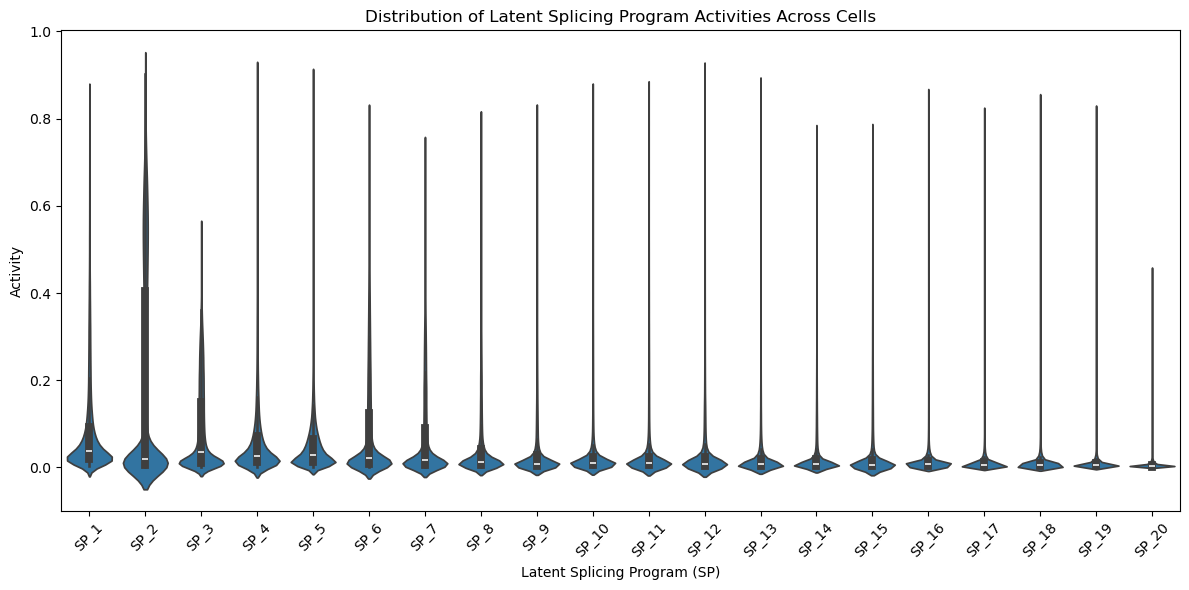

In [9]:
# Extract X_PHI matrix and convert to DataFrame
phi = pd.DataFrame(
    splice_adata.obsm["X_PHI"],
    index=splice_adata.obs["cell_id"]
)
phi.columns = [f"SP_{i+1}" for i in range(phi.shape[1])]

phi_long = phi.reset_index().melt(id_vars="cell_id", var_name="Splicing Program", value_name="Activity")

# Plot
plt.figure(figsize=(12, 6))  # Adjust width as needed
sns.violinplot(data=phi_long, x="Splicing Program", y="Activity", inner="box", scale="width")
plt.xticks(rotation=45)
plt.title("Distribution of Latent Splicing Program Activities Across Cells")
plt.xlabel("Latent Splicing Program (SP)")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()

In [10]:
# Create a refined mapping for human cell types
human_refined_mapping = {
    # Neurons - keep separate as they're functionally very different
    "Inhibitory_Neuron": "Inhibitory_Neuron",
    "Excitatory_Neuron": "Excitatory_Neuron", 
    "Other_Neuron": "Other_Neuron",
    
    # Glia
    "Cns_Glia": "Glia",
    "Pns_Glia": "Glia",
    "Microglia": "Microglia",  # Keep separate - unique immune function
    
    # All endothelial together
    "Endothelial": "Endothelial",
    "Specialized_Endothelial": "Endothelial",
    "Arterial_Endothelial": "Endothelial",
    "Venous_Endothelial": "Endothelial", 
    "Lymphatic_Endothelial": "Endothelial",
    "Capillary_Endothelial": "Endothelial",
    
    # All fibroblasts/stromal
    "General_Fibroblast": "Fibroblast",
    "Organ_Specific_Fibroblast": "Fibroblast",
    
    # All T cells together
    "Cd4_T_Cell": "T_Cell",
    "Cd8_T_Cell": "T_Cell",
    "Other_T_Cell": "T_Cell",
    "Regulatory_T_Cell": "T_Cell",
    "Nk_Ilc": "T_Cell",  # NK cells are lymphoid
    
    # B cells and plasma cells
    "B_Cell": "B_Cell",
    "Plasma_Cell": "B_Cell",  # Plasma cells are activated B cells
    
    # Myeloid immune cells
    "Macrophage": "Macrophage",
    "Monocyte": "Macrophage",  # Monocytes become macrophages
    "Dendritic_Cell": "Dendritic_Cell",
    "Granulocyte": "Granulocyte",
    "Myeloid_Other": "Myeloid_Other",
    
    # Other immune
    "Immune_Other": "Immune_Other",
    
    # All muscle together
    "Smooth_Muscle": "Muscle",
    "Skeletal_Muscle": "Muscle", 
    "Muscle_Other": "Muscle",
    
    # All epithelial together
    "Gi_Epithelial": "Epithelial",
    "Other_Epithelial": "Epithelial",
    "Respiratory_Epithelial": "Epithelial",
    "Urogenital_Epithelial": "Epithelial",
    "Alveolar_Cell": "Epithelial",
    
    # Stem/progenitor
    "Mesenchymal_Stem": "Stem_Progenitor",
    "Hematopoietic_Progenitor": "Stem_Progenitor",
    "Hematopoietic_Mature": "Stem_Progenitor",
    "Stem_Progenitor_Other": "Stem_Progenitor",
    
    # Keep unique
    "Pericyte": "Pericyte",
    "Secretory_Gland": "Secretory_Gland",
    "Other": "Other"
}

# For the "Other" broad category, we need to map based on detailed cell_type
def map_other_cells(row):
    if row["broad_cell_type"] != "Other":
        return human_refined_mapping.get(row["broad_cell_type"], row["broad_cell_type"])
    else:
        # Map specific cell types within "Other"
        cell_type = row["cell_type"]
        if cell_type in ["basal cell", "kidney epithelial cell", "lung ciliated cell", "unciliated epithelium"]:
            return "Epithelial"
        else:
            return "Other"
        
# Apply the refined mapping
splice_adata.obs["refined_cell_type"] = splice_adata.obs.apply(map_other_cells, axis=1)

# Once again subset to only cell types with at least 50 cells
splice_adata = splice_adata[splice_adata.obs["refined_cell_type"].isin(splice_adata.obs["refined_cell_type"].value_counts()[splice_adata.obs["refined_cell_type"].value_counts() >= 50].index)]
ge_adata = ge_adata[splice_adata.obs_names]

In [11]:
# Clean up Broad Cell Type column
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()
splice_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]
splice_adata.obs["refined_cell_type"] = splice_adata.obs["refined_cell_type"].str.title()
ge_adata.obs["refined_cell_type"] = splice_adata.obs["refined_cell_type"]
assert all(splice_adata.obs_names == ge_adata.obs_names)

In [12]:
# Setup
phi_matrix = splice_adata.obsm["X_PHI"]
factor_names = [f"SP_{i+1}" for i in range(phi_matrix.shape[1])]

# Build DataFrame
phi_df = pd.DataFrame(phi_matrix, index=splice_adata.obs_names, columns=factor_names)
phi_df["broad_cell_type"] = splice_adata.obs["broad_cell_type"].values
phi_df["age_group"] = splice_adata.obs["age_group"].values

# Output dirs
output_dir_celltype = "./factor_violin_plots_by_celltype"
output_dir_agegroup = "./factor_violin_plots_by_agegroup"
output_dir_factors_by_celltype = "./factor_violin_per_celltype"

os.makedirs(output_dir_factors_by_celltype, exist_ok=True)
os.makedirs(output_dir_celltype, exist_ok=True)
os.makedirs(output_dir_agegroup, exist_ok=True)
assert all(splice_adata.obs_names == ge_adata.obs_names)

In [13]:
# Toggle this to enable or disable plotting
MAKE_PLOTS = False

if MAKE_PLOTS:
    # --- Plot factor activity across broad cell types ---
    for factor in factor_names:
        # Order broad_cell_type by decreasing median activity
        medians = phi_df.groupby("broad_cell_type")[factor].median().sort_values(ascending=False)
        ordered_types = medians.index.tolist()

        plt.figure(figsize=(10, 5))
        sns.violinplot(
            data=phi_df, x="broad_cell_type", y=factor,
            order=ordered_types, inner="box", scale="width",
            fill="simple_category"
        )
        plt.xticks(rotation=45, ha='right')
        plt.title(f"{factor} Activity Across Broad Cell Types")
        plt.xlabel("Broad Cell Type")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_celltype, f"{factor}_by_celltype_violin.pdf"))
        plt.close()

    # --- Plot factor activity across age groups ---
    for factor in factor_names:
        # Define age group order (assumes string labels like "3m", "18m", etc.)
        age_order = phi_df["age_group"].unique().tolist()
        age_order.sort()

        plt.figure(figsize=(6, 5))
        sns.violinplot(
            data=phi_df, x="age_group", y=factor,
            order=age_order, inner="box", scale="width"
        )
        plt.title(f"{factor} Activity Across Age Groups")
        plt.xlabel("Age Group")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_agegroup, f"{factor}_by_agegroup_violin.pdf"))
        plt.close()

    # --- Melt wide-format dataframe into long-form for factor plotting ---
    phi_long = phi_df.reset_index().melt(
        id_vars=["cell_id", "broad_cell_type", "age_group"],
        value_vars=factor_names,
        var_name="Factor", value_name="Activity"
    )

    # --- Plot violin plots of all factors within each cell type ---
    for celltype in phi_df["broad_cell_type"].unique():
        # Subset data to current cell type
        subset = phi_long[phi_long["broad_cell_type"] == celltype]

        # Order factors by median activity within the current cell type
        median_order = (
            subset.groupby("Factor")["Activity"]
            .median()
            .sort_values(ascending=False)
            .index.tolist()
        )

        plt.figure(figsize=(14, 5))
        sns.violinplot(
            data=subset, x="Factor", y="Activity",
            order=median_order, inner="box", scale="width"
        )
        plt.xticks(rotation=90, ha='right')
        plt.title(f"Factor Activity in {celltype} (Ordered by Median)")
        plt.xlabel("Factor")
        plt.ylabel("Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_factors_by_celltype, f"{celltype}_factor_activity_violin.pdf"))
        plt.close()

## Visualize Pi vs PVE

In [14]:
# get reordered pi values 
new_pi = pi[new_order]

# visualize global learned pi values, vs how much variance each one explains across cells PHI? 
# How much variance each factor contributes in the loadings
phi_var = np.var(splice_adata.obsm["X_PHI"], axis=0)  # Variance across cells for each factor
pve_factor_space = phi_var / np.sum(phi_var)
print(pve_factor_space)
assert all(splice_adata.obs_names == ge_adata.obs_names)

[6.52946726e-02 3.17118024e-01 5.28929242e-02 7.10347424e-02
 3.33029284e-02 8.33664514e-02 6.02703969e-02 3.91286401e-02
 3.65523899e-02 3.48740853e-02 4.31127399e-02 5.64200622e-02
 2.64104816e-02 1.66914368e-02 4.03549393e-02 8.45412669e-03
 4.66277646e-03 7.22645724e-03 2.56039771e-03 2.71326859e-04]


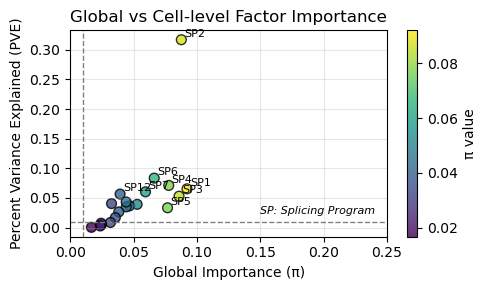

In [15]:
# Simple scatter plot
plt.figure(figsize=(5, 3))

# Use scatter with edgecolors for black outline and c parameter for color mapping
plt.scatter(new_pi, pve_factor_space, s=50, alpha=0.8, 
            c=new_pi, cmap='viridis', edgecolors='black', linewidth=1)

# Add colorbar to show π value mapping
plt.colorbar(label='π value')

# Add factor labels for interesting points
for i in range(len(new_pi)):
    if i < 5 or pve_factor_space[i] > 0.05:  # Label first 3 and high variance factors
        plt.annotate(f'SP{i+1}', (new_pi[i], pve_factor_space[i]), 
                    xytext=(2, 2), textcoords='offset points', fontsize=8)  # Increased from (5,5) to (10,10)

plt.xlabel('Global Importance (π)')
plt.ylabel('Percent Variance Explained (PVE)')
plt.title('Global vs Cell-level Factor Importance')
plt.xlim(0, 0.25)

# add dashed hori line at 0.01
plt.axhline(0.01, color='gray', linestyle='--', linewidth=1)
plt.axvline(0.01, color='gray', linestyle='--', linewidth=1)

# Add SP definition at bottom of plot
plt.text(0.15, 0.02, 'SP: Splicing Program', fontsize=8, style='italic', 
         transform=plt.gca().transData, verticalalignment='bottom')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
assert all(splice_adata.obs_names == ge_adata.obs_names)

Plot saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/factor_pi_vs_pve.pdf


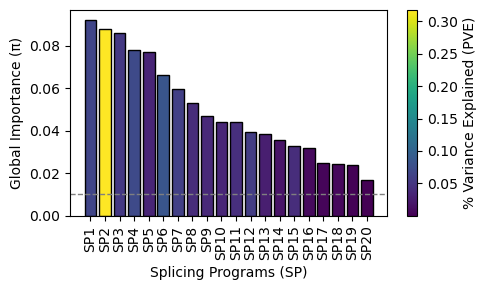

In [16]:
# Assume new_pi and pve_factor_space already exist
num_factors = len(new_pi)
factor_labels = [f'SP{i+1}' for i in range(num_factors)]

# Normalize PVE for colormap
norm = plt.Normalize(pve_factor_space.min(), pve_factor_space.max())
colors = plt.cm.viridis(norm(pve_factor_space))

# Set up figure and axis
fig, ax = plt.subplots(figsize=(5, 3))

# Bar plot
bars = ax.bar(
    factor_labels,
    new_pi,
    color=colors,
    edgecolor='black'
)

# Create scalar mappable and colorbar
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # Required dummy
cbar = plt.colorbar(sm, ax=ax)  # Pass ax explicitly
cbar.set_label("% Variance Explained (PVE)")

# Add horizontal threshold line
ax.axhline(0.01, color='gray', linestyle='--', linewidth=1)

# Formatting
ax.set_ylabel('Global Importance (π)')
ax.set_xlabel('Splicing Programs (SP)')
# ax.set_title('Factor Importance (π), colored by PVE')
ax.set_xticks(np.arange(num_factors))
ax.set_xticklabels(factor_labels, rotation=90, fontsize=10)

plt.tight_layout()

# Save to output_dir with today's date OUTPUT_DIR 
output_path = os.path.join(OUTPUT_DIR, f"factor_pi_vs_pve.pdf")
plt.savefig(output_path, format='pdf', bbox_inches='tight')
print(f"Plot saved to: {output_path}")

plt.show()
assert all(splice_adata.obs_names == ge_adata.obs_names)

## Visualize Perplexity

In [17]:
# Step 2: Reindex to match AnnData.obs_names (i.e., cell IDs)
perplexity_df = perplexity_df.reindex(splice_adata.obs_names)

# Step 3: Add as a new column in AnnData.obs
splice_adata.obs["perplexity"] = perplexity_df["perplexity"].values
assert all(splice_adata.obs_names == ge_adata.obs_names)

In [18]:
ge_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]
assert all(splice_adata.obs_names == ge_adata.obs_names)

Saved plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/perplexity_by_age_rasterized.pdf


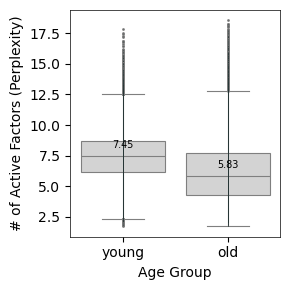

In [19]:
plt.figure(figsize=(3, 3))

# Define desired order
age_order = ["young", "old"]

# Boxplot
sns.boxplot(
    data=splice_adata.obs,
    x="age_group", 
    y="perplexity", 
    order=age_order,         # <-- force the order here
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)

# Stripplot
stripplot = sns.stripplot(
    data=splice_adata.obs,
    x="age_group", 
    y="perplexity", 
    order=age_order,         # <-- same order for consistency
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# 🟡 Rasterize only the point cloud layer
for c in stripplot.collections:
    c.set_rasterized(True)

# Median labels
medians = (
    splice_adata.obs
    .groupby("age_group", observed=True)["perplexity"]
    .median()
)

for i, age in enumerate(age_order):
    median_val = medians[age]
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

# Formatting
plt.xlabel("Age Group", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()

# Save to PDF with rasterized points
output_path = f"{OUTPUT_DIR}/perplexity_by_age_rasterized.pdf"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved plot to: {output_path}")
plt.show()

Saved plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/perplexity_by_sex_rasterized.pdf


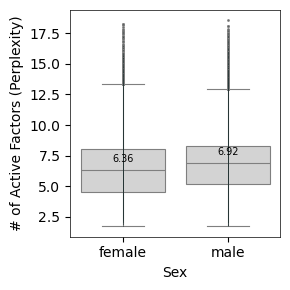

In [20]:
plt.figure(figsize=(3, 3))

# Boxplot: keep as vector
sns.boxplot(
    data=splice_adata.obs,
    x="sex", 
    y="perplexity", 
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)

# Stripplot: will rasterize below
stripplot = sns.stripplot(
    data=splice_adata.obs,
    x="sex", 
    y="perplexity", 
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# 🟡 Rasterize only the point cloud layer
for c in stripplot.collections:
    c.set_rasterized(True)

# Median labels
medians = (
    splice_adata.obs
    .groupby("sex", observed=True)["perplexity"]
    .median()
)
for i, (age, median_val) in enumerate(medians.items()):
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

# Formatting
plt.xlabel("Sex", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()

# Save to PDF with rasterized points
output_path = f"{OUTPUT_DIR}/perplexity_by_sex_rasterized.pdf"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved plot to: {output_path}")
plt.show()

In [21]:
splice_adata.obs["refined_cell_type"].value_counts()

refined_cell_type
Excitatory_Neuron    29147
Inhibitory_Neuron    10801
Macrophage            4170
Cns_Glia              3866
Endothelial           3171
Cd4_T_Cell            2829
Fibroblast            2447
B_Cell                2312
Cd8_T_Cell            2130
Gi_Epithelial         2015
Epithelial            1995
Nk_Ilc                1629
Granulocyte           1574
Stem_Progenitor       1472
Muscle                1178
Plasma_Cell            963
Other_T_Cell           937
Microglia              798
Pericyte               574
Alveolar_Cell          369
Other_Neuron           317
Dendritic_Cell         158
Secretory_Gland        132
Immune_Other            99
Regulatory_T_Cell       76
Myeloid_Other           74
Pns_Glia                67
Name: count, dtype: int64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved rasterized plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/perplexity_by_cell_type_ordered_rasterized.pdf


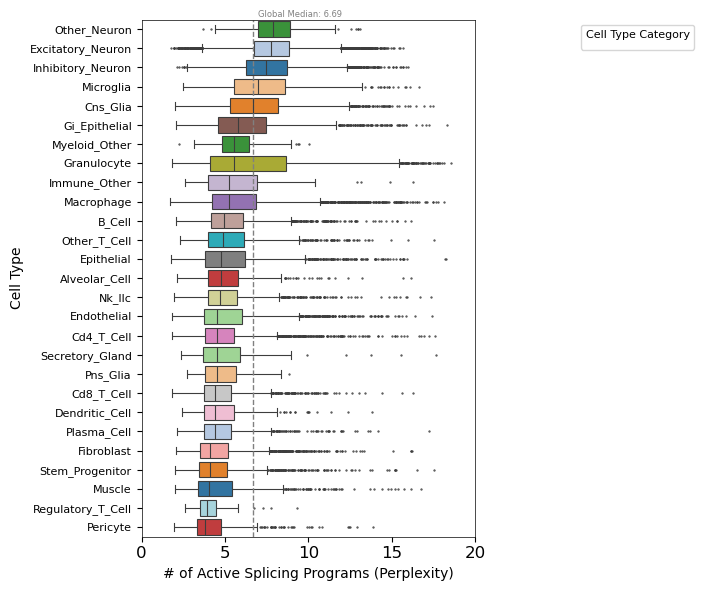

In [22]:
# Step 1: Compute median perplexity by medium_cell_type
median_order = (
    splice_adata.obs
    .groupby("refined_cell_type", observed=True)["perplexity"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Step 2: Color palette for broad_cell_type
unique_broad = splice_adata.obs["refined_cell_type"].unique()
palette = sns.color_palette("tab20", len(unique_broad))
palette_dict = dict(zip(unique_broad, palette))

# Step 3: Start figure
fig, ax = plt.subplots(figsize=(8, 6))

# Step 4: Main plot
bp = sns.boxplot(
    data=splice_adata.obs,
    y="refined_cell_type", 
    x="perplexity", 
    hue="refined_cell_type", 
    fliersize=0.6, 
    linewidth=0.8,
    order=median_order,
    palette=palette_dict,
    ax=ax
)

# Rasterize fliers
for c in ax.collections:
    if isinstance(c, plt.collections.PathCollection):
        c.set_rasterized(True)

# Global median line
global_median = splice_adata.obs["perplexity"].median()
ax.axvline(global_median, color='gray', linestyle='--', linewidth=1)
ax.text(global_median + 0.3, -1, f"Global Median: {global_median:.2f}",
        color='gray', fontsize=6, va='top')

# Legend
ax.legend(
    title="Cell Type Category",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=8,
    frameon=True
)

# Axis formatting
ax.set_ylabel("Cell Type", fontsize=10)
ax.set_xlabel("# of Active Splicing Programs (Perplexity)", fontsize=10)
ax.set_xticks(np.arange(0, 25, 5))
ax.set_xticklabels(np.arange(0, 25, 5), fontsize=12)
ax.tick_params(axis='y', labelsize=8)  # ⬅️ Smaller font for cell type labels

# Border
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# Save
plt.tight_layout()
pdf_path = f"{OUTPUT_DIR}/perplexity_by_cell_type_ordered_rasterized.pdf"
plt.savefig(pdf_path, bbox_inches='tight', dpi=300)
print(f"Saved rasterized plot to: {pdf_path}")
plt.show()

In [23]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")

import utils  # or: from utils import your_function
import importlib
importlib.reload(utils)

<module 'utils' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/utils.py'>

## Get correlation matrix plot

In [24]:
# Remake PHI matrix correlation plot
X_PHI_corr_matrix = plot_correlation_matrix(splice_adata.obsm["X_PHI"], OUTPUT_DIR)

Saved correlation matrix to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/correlation_matrix_PHI.pdf


### Figure 2 Factor Covaraites Labels

Running variance explained analysis...


Analyzing factors for variance explained:   0%|          | 0/20 [00:00<?, ?it/s]

  Formula: SP_1 ~ C(cell_type) + C(tissue) + C(sex) + age + C(dataset) + C(cell_type):age + C(sex):age


Analyzing factors for variance explained:   5%|▌         | 1/20 [00:00<00:18,  1.03it/s]

                        sum_sq       df            F         PR(>F)    SP
C(cell_type)      26263.399674     26.0  2026.448195   0.000000e+00  SP_1
C(tissue)           812.860229     30.0    54.356631  2.391278e-321  SP_1
C(sex)              117.023992      1.0   234.764712   6.551685e-53  SP_1
C(dataset)          132.571752      1.0   265.955457   1.094090e-59  SP_1
age                  84.952964      1.0   170.426233   6.583062e-39  SP_1
C(cell_type):age    294.374047     26.0    22.713501  1.602408e-107  SP_1
C(sex):age           57.386115      1.0   115.123699   7.732382e-27  SP_1
Residual          37492.187023  75214.0          NaN            NaN  SP_1
  Formula: SP_2 ~ C(cell_type) + C(tissue) + C(sex) + age + C(dataset) + C(cell_type):age + C(sex):age


...

Analyzing factors for variance explained:  95%|█████████▌| 19/20 [00:18<00:00,  1.01it/s]

                        sum_sq       df          F         PR(>F)     SP
C(cell_type)        828.105922     26.0  32.525708  1.509815e-160  SP_19
C(tissue)           262.323807     30.0   8.929572   6.251872e-40  SP_19
C(sex)                0.300445      1.0   0.306817   5.796418e-01  SP_19
C(dataset)           41.821286      1.0  42.708232   6.394855e-11  SP_19
age                  48.569445      1.0  49.599506   1.901709e-12  SP_19
C(cell_type):age     62.184979     26.0   2.442454   5.600094e-05  SP_19
C(sex):age            7.242943      1.0   7.396551   6.536404e-03  SP_19
Residual          73651.988354  75214.0        NaN            NaN  SP_19
  Formula: SP_20 ~ C(cell_type) + C(tissue) + C(sex) + age + C(dataset) + C(cell_type):age + C(sex):age


Analyzing factors for variance explained: 100%|██████████| 20/20 [00:19<00:00,  1.01it/s]

                        sum_sq       df           F         PR(>F)     SP
C(cell_type)        858.922993     26.0   34.306191  3.275938e-170  SP_20
C(tissue)           612.348198     30.0   21.196727  3.616400e-114  SP_20
C(sex)                0.179705      1.0    0.186617   6.657484e-01  SP_20
C(dataset)           35.580914      1.0   36.949513   1.218088e-09  SP_20
age                 115.539066      1.0  119.983207   6.697519e-28  SP_20
C(cell_type):age    108.273674     26.0    4.324552   1.036806e-12  SP_20
C(sex):age            3.921396      1.0    4.072230   4.359724e-02  SP_20
Residual          72428.096486  75214.0         NaN            NaN  SP_20


  Saved variance explained heatmap to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/variance_explained_heatmap_refined_cell_type.pdf


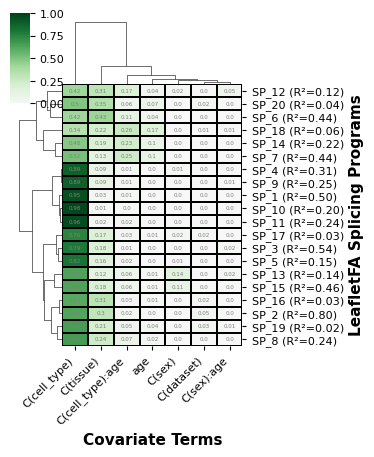

In [25]:
# read in factor labels 
factor_labels_medium_cell_type = utils.run_variance_explained_analysis(splice_adata, cell_type_col="refined_cell_type", sample_id="dataset", PLOTS_DIR=OUTPUT_DIR)

In [26]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")
import figure_plotting
import importlib
importlib.reload(figure_plotting)

<module 'figure_plotting' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/figure_plotting.py'>

### Plot correlation plot between PHI SP1 and SP2 


Top 2 positively correlated factor pairs:
factor_i factor_j      rho
    SP19     SP20 0.556336
    SP17     SP20 0.504067

Top 2 negatively correlated factor pairs:
factor_i factor_j       rho
     SP2     SP12 -0.396526
     SP3      SP4 -0.367263

Top 2 least correlated factor pairs:
factor_i factor_j       rho
     SP1      SP4 -0.000157
     SP9     SP12 -0.000503


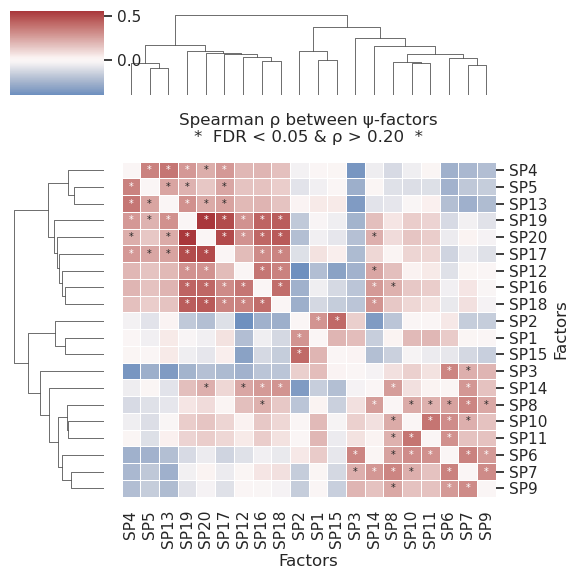

In [27]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests   # pip install statsmodels

# ── 1.  Data → DataFrame ───────────────────────────────────────────────────────
ψ  = splice_adata.varm["psi_learned"]          # (J, K)
K  = ψ.shape[1]

# Subtract row (junction) mean from each factor value
ψ_centered = ψ - np.nanmean(ψ, axis=1, keepdims=True)
K = ψ_centered.shape[1]
df = pd.DataFrame(ψ_centered, columns=[f"SP{j+1}" for j in range(K)])

# ── 2.  ρ and p-values for *each* pair ─────────────────────────────────────────
rho    = np.zeros((K, K))
pvals  = np.ones((K, K))

for i in range(K):
    for j in range(i+1, K):
        r, p = spearmanr(df.iloc[:, i], df.iloc[:, j], nan_policy='omit')
        rho[i, j] = rho[j, i] = r
        pvals[i, j] = pvals[j, i] = p

# ── 3.  Benjamini–Hochberg FDR adjustment over the upper triangle ─────────────
tri_idx         = np.triu_indices(K, k=1)          # exclude the diagonal
p_flat          = pvals[tri_idx]
_, q_flat, _, _ = multipletests(p_flat, method="fdr_bh")
qvals           = np.ones_like(pvals)
qvals[tri_idx]  = qvals.T[tri_idx] = q_flat

# ── 4.  Significance mask  (FDR < 0.05 and ρ > 0.20) ──────────────────────────
star_mask = (qvals < 0.05) & (rho > 0.20)
annot     = np.where(star_mask, "*", "")

# ── 5.  Build DataFrames with indices/columns for seaborn ─────────────────────
rho_df   = pd.DataFrame(rho,   index=df.columns, columns=df.columns)
annot_df = pd.DataFrame(annot, index=df.columns, columns=df.columns)


# ── 1.  clustered heat-map with all tick labels ───────────────────────────────
sns.set_theme(style="white")
g = sns.clustermap(
    rho_df,
    cmap="vlag", center=0, linewidths=0.4, square=True,
    metric="euclidean", row_cluster=True, col_cluster=True,
    figsize=(6, 6),
    annot=annot_df, fmt="", annot_kws={"size":7},
    xticklabels=True, yticklabels=True
)

# Rotate x-labels so they don’t overlap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.ax_heatmap.set_title("Spearman ρ between ψ-factors\n*  FDR < 0.05 & ρ > 0.20  *", pad=14)
g.ax_heatmap.set_xlabel("Factors")
g.ax_heatmap.set_ylabel("Factors")

plt.tight_layout()

# ── 2.  save to disk ──────────────────────────────────────────────────────────
g.savefig(f"{OUTPUT_DIR}/psi_factor_spearman_clustermap.pdf", bbox_inches="tight")

# ── 3.  report extreme pairs ──────────────────────────────────────────────────
# flatten upper triangle (exclude diagonal), keep finite values only
tri_i, tri_j = np.triu_indices_from(rho_df, k=1)
tri_vals = rho_df.values[tri_i, tri_j]

# build a DataFrame for easy sorting
pairs_df = pd.DataFrame({
    "factor_i": rho_df.index[tri_i],
    "factor_j": rho_df.columns[tri_j],
    "rho":      tri_vals
}).dropna()

# top 2 positive
top_pos = pairs_df.nlargest(2, "rho")
# top 2 negative
top_neg = pairs_df.nsmallest(2, "rho")
# top 2 least correlated (closest to zero)
top_flat = pairs_df.iloc[(pairs_df["rho"].abs()).nsmallest(2).index]

print("\nTop 2 positively correlated factor pairs:")
print(top_pos.to_string(index=False))

print("\nTop 2 negatively correlated factor pairs:")
print(top_neg.to_string(index=False))

print("\nTop 2 least correlated factor pairs:")
print(top_flat.to_string(index=False))


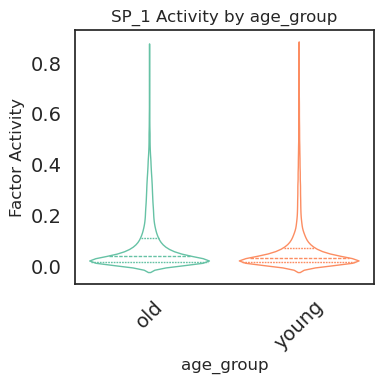

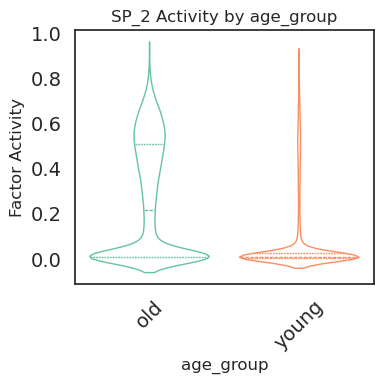

In [28]:
plot_factor_violin(
    adata=splice_adata,
    factor_list=["SP_1", "SP_2"],
    groupby="age_group",
    save_prefix="factor_age_violin"
)

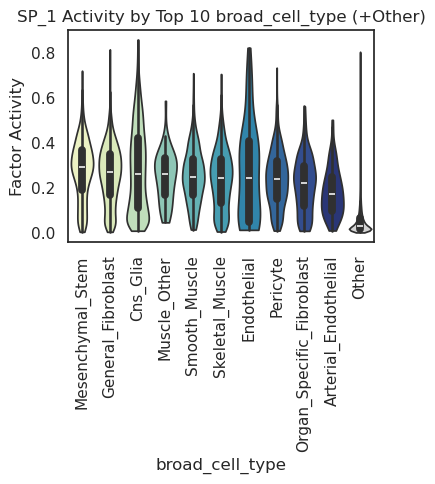

In [29]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_1"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

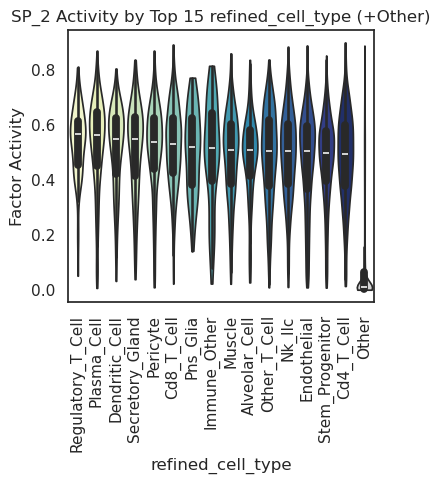

In [30]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_2"],
    groupby="refined_cell_type",
    top_n=15,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

### Get heatmap for common cell types 

In [31]:
splice_adata.obs["dataset"].value_counts()

dataset
allen_brain       44976
tabula_sapiens    30324
Name: count, dtype: int64

refined_cell_type  dataset       
Cns_Glia           allen_brain       3855
Endothelial        tabula_sapiens    3102
Fibroblast         tabula_sapiens    2436
Microglia          allen_brain        748
Pericyte           tabula_sapiens     544
Other_Neuron       allen_brain        315
Endothelial        allen_brain         69
Microglia          tabula_sapiens      50
Pericyte           allen_brain         30
Cns_Glia           tabula_sapiens      11
Fibroblast         allen_brain         11
Other_Neuron       tabula_sapiens       2
Name: count, dtype: int64
Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/clustering_common_celltype_dataset_factors.pdf


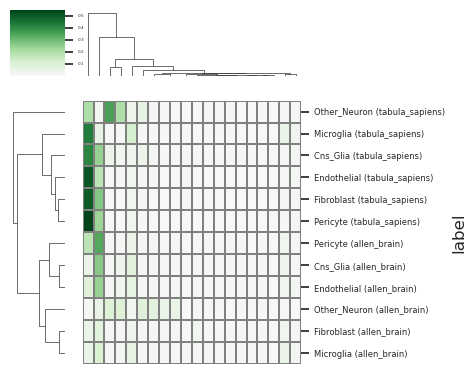

In [32]:
# Get cell type counts by dataset to get common cell types
# Get cell type counts by dataset to get common cell types
cell_type_counts = splice_adata.obs.groupby(['refined_cell_type', 'dataset']).size().unstack()
common_cell_types = cell_type_counts[(cell_type_counts["allen_brain"] > 0) & (cell_type_counts["tabula_sapiens"] > 0)]
common_cell_type_names = common_cell_types.index.tolist()

# Subset to common cell types
adata_common = splice_adata[
    splice_adata.obs["refined_cell_type"].isin(common_cell_type_names)
].copy()

# Convert to categorical first
adata_common.obs["refined_cell_type"] = adata_common.obs["refined_cell_type"].astype("category")
adata_common.obs["refined_cell_type"] = adata_common.obs["refined_cell_type"].cat.remove_unused_categories()

# Print breakdown of common cell types by dataset and cell type
print(adata_common.obs[["refined_cell_type", "dataset"]].value_counts())

# Extract factor matrix and build DataFrame
num_factors = adata_common.obsm["X_PHI"].shape[1]
factor_cols = [f"Factor_{i+1}" for i in range(num_factors)]

df = adata_common.obs[["refined_cell_type", "dataset"]].copy()
for i, col in enumerate(factor_cols):
    df[col] = adata_common.obsm["X_PHI"][:, i]

# Compute median factor values by cell type and dataset
median_profiles = (
    df.groupby(["refined_cell_type", "dataset"], observed=True)[factor_cols]
    .median()
    .reset_index()
)

# Create composite labels
median_profiles["label"] = (
    median_profiles["refined_cell_type"].astype(str)
    + " (" +
    median_profiles["dataset"].astype(str)
    + ")"
)

# Set label as index
median_profiles = median_profiles.set_index("label")[factor_cols]

# Plot clustermap
g = sns.clustermap(
    median_profiles,
    method="average",
    metric="euclidean",
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor='gray',
    figsize=(5, 4)
)

# Remove x-axis tick labels (factors)
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_xticklabels([])

# Format y-axis (cell types)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)

# Colorbar label and tick font
g.ax_cbar.set_label("Median Factor Activity")
g.ax_cbar.yaxis.label.set_size(7)
g.ax_cbar.tick_params(labelsize=3)

# Save
plt.tight_layout()
g.savefig(f"{OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf", bbox_inches='tight')
print(f"Saved plot to {OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf")
plt.show()

In [33]:
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].astype("category")

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Extract age and perplexity
X = splice_adata.obs[["age_numeric"]].values  # shape (n_cells, 1)
y = splice_adata.obs["perplexity"].values  # shape (n_cells,)

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Compute R²
r2 = r2_score(y, y_pred)
print(f"R² (perplexity ~ age): {r2:.4f}")

R² (perplexity ~ age): 0.0783


## Look at sig junctions from differential splicing analysis

In [35]:
# Run the analysis
print("="*60)
print("TOP JUNCTIONS PER FACTOR PSI ANALYSIS")
print("="*60)

# Step 1: Get top junctions per factor
top_junctions_dict, subset_splice_adata, junction_factor_map = get_top_junctions_per_factor(
    diff_spl, 
    splice_adata, 
    top_n=10, 
    effect_size_col='abs_effect_size'
)

# Get unique junction indices
unique_junctions = junction_factor_map['junction_idx'].unique()

# Extract PSI learned values for these junctions
psi_subset = splice_adata.varm['psi_learned'][unique_junctions, :]

TOP JUNCTIONS PER FACTOR PSI ANALYSIS
Getting top 10 junctions per factor...
Ranking by: abs_effect_size
Found 20 factors: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Factor 0: 10 junctions, effect size range: 0.913 - 0.993
Factor 1: 10 junctions, effect size range: 0.990 - 0.998
Factor 2: 10 junctions, effect size range: 0.885 - 0.951
Factor 3: 10 junctions, effect size range: 0.924 - 0.999
Factor 4: 10 junctions, effect size range: 0.934 - 0.975
Factor 5: 10 junctions, effect size range: 0.852 - 0.978
Factor 6: 10 junctions, effect size range: 0.879 - 0.928
Factor 7: 10 junctions, effect size range: 0.836 - 0.915
Factor 8: 10 junctions, effect size range: 0.896 - 0.941
Factor 9: 10 junctions, effect size range: 0.812 - 0.971
Factor 10: 10 junctions, effect size range: 0.859 - 0.963
Factor 11: 10 junctions, effect size range: 0.849 - 0.972
Factor 12: 10 junctions, effect size range: 0.887 - 0.928
Factor 13: 10 junctions, effect size range: 0.949 - 0.971
Fact

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/psi_clustermap_top_10.pdf


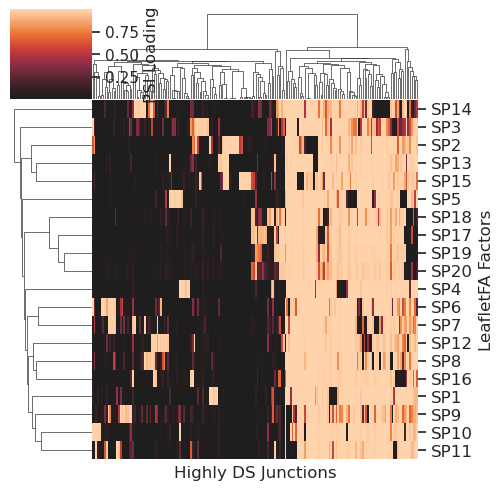

In [36]:
# 1. Map row labels: get junction_id or gene_name from .var
# Get the integer indices into .varm (which uses original order)
unique_junctions = junction_factor_map['junction_idx'].unique()
# psi_learned: shape (n_junctions, n_factors), so index using integer indices
psi_subset = splice_adata.varm['psi_learned'][unique_junctions, :]
junction_id = splice_adata.var[splice_adata.var["junction_id_index"].isin(unique_junctions)]["junction_id"].values
gene_name = splice_adata.var[splice_adata.var["junction_id_index"].isin(unique_junctions)]["gene_name"].values

# Get number of factors (rows after transpose)
num_factors = psi_subset.shape[1]

# Create factor labels: F1, F2, ..., FK
factor_labels = [f"SP{i+1}" for i in range(num_factors)]

# 2. Create clustermap with color tweaks
g = sns.clustermap(
    psi_subset.T,
    center=0,
    figsize=(6, 5),
    xticklabels=False,
    yticklabels=factor_labels,
    cbar_kws={'label': 'PSI Loading'},
    robust=True  # clip extreme values for better contrast
)

# 3. Style adjustments
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)
g.ax_heatmap.set_ylabel("LeafletFA Factors")
g.ax_heatmap.set_xlabel("Highly DS Junctions")
plt.subplots_adjust(left=0.3, bottom=0.05, top=0.95, right=0.98)
save_path = os.path.join(OUTPUT_DIR, "psi_clustermap_top_10.pdf")
g.savefig(save_path, bbox_inches="tight")
print(f"Saved plot to {save_path}")
plt.show()

## Get UMAP on X_PHI

In [37]:
ge_adata.layers["scVI_linear"] = ge_adata.obsm["X_normalized_scVI_linear"]

In [38]:
# Run neighbors and UMAP on X_PHI embedding
# sc.pp.neighbors(filtered_splice_adata, use_rep="X_PHI", n_neighbors=8)
# sc.tl.umap(filtered_splice_adata, random_state=0, min_dist=0.3)

In [39]:
#plot_gene_and_factor_umap_from_phi(
#    splice_adata=filtered_splice_adata,
#    ge_adata=filtered_ge_adata,
#    gene_name="ZWINT",
#    factor_name="Factor_2",
#    groupby="broad_cell_type",
#    group_level="Microglia"
#)

In [40]:
ge_adata.obs["SP_1"] = splice_adata.obs["SP_1"]
ge_adata.obs["SP_2"] = splice_adata.obs["SP_2"]
ge_adata.obs["age_group"] = splice_adata.obs["age_group"]

In [41]:
# Multiple plots in one figure
# sc.pl.umap(ge_adata, 
#           color=['broad_cell_type', 'age_group', 'SP_1', 'SP_2'],
#           ncols=1,
#           frameon=False,
#           save='_multiplot.pdf')

### New circle heatmap combining delta age and activity across cell types

In [42]:
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.patches import Circle, Rectangle
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_factor_circles(adata, cell_type_col='broad_cell_type', age_col='age_group'):
    """
    Clustered tile plot: background color shows delta PSI (old - young),
    circle outlines show activity (median nonzero expression).
    """
    # Extract factor matrix
    X_PHI = adata.obsm["X_PHI"]
    n_factors = X_PHI.shape[1]
    factor_cols = [f"SP_{i+1}" for i in range(n_factors)]
    factor_df = pd.DataFrame(X_PHI, index=adata.obs.index, columns=factor_cols)

    # Median expression (non-zero) per cell type
    median_expr = pd.DataFrame(index=adata.obs[cell_type_col].unique(), columns=factor_cols)
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        ct_data = factor_df.loc[ct_mask]
        for factor in factor_cols:
            vals = ct_data[factor]
            nonzero = vals[vals > 0]
            median_expr.loc[ct, factor] = nonzero.median() if len(nonzero) > 0 else 0
    median_expr = median_expr.astype(float).fillna(0)

    # Delta PSI: old - young
    delta_age = pd.DataFrame(index=median_expr.index, columns=factor_cols)
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        old_mask = ct_mask & (adata.obs[age_col] == 'old')
        young_mask = ct_mask & (adata.obs[age_col] == 'young')
        if old_mask.sum() > 10 and young_mask.sum() > 10:
            for factor in factor_cols:
                old_vals = factor_df.loc[old_mask, factor]
                young_vals = factor_df.loc[young_mask, factor]
                delta_age.loc[ct, factor] = old_vals.median() - young_vals.median()
        else:
            delta_age.loc[ct] = 0
    delta_age = delta_age.astype(float).fillna(0)

    # Clustering
    factor_order = list(range(len(factor_cols)))  # preserve original SP_1 ... SP_K order
    celltype_order = dendrogram(linkage(median_expr, method='ward'), no_plot=True)['leaves']
    celltype_order = [median_expr.index[i] for i in celltype_order]

    # Compute cell counts
    celltype_counts = adata.obs[cell_type_col].value_counts()
    celltype_labels = [f"{ct} ({celltype_counts[ct]})" for ct in celltype_order]

    # Reorder matrices
    median_ordered = median_expr.loc[celltype_order, :].iloc[:, factor_order]
    delta_ordered = delta_age.loc[celltype_order, :].iloc[:, factor_order]

    # Plot setup
    fig, ax = plt.subplots(figsize=(10, 7))
    n_cells = len(median_ordered)
    n_factors = len(median_ordered.columns)
    ax.set_xlim(-0.5, n_factors - 0.5)
    ax.set_ylim(-0.5, n_cells - 0.5)

    # Color scale for delta PSI
    cmap = plt.cm.BrBG
    vmax = max(abs(delta_ordered.values.min()), abs(delta_ordered.values.max()))
    norm = plt.Normalize(vmin=-vmax, vmax=vmax)

    # Draw tiles
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            delta = delta_ordered.loc[cell_type, factor]
            color = cmap(norm(delta))
            tile = Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color, edgecolor='none')
            ax.add_patch(tile)

    # Draw circle outlines for activity
    min_radius = 0.1
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            expr = median_ordered.loc[cell_type, factor]
            if expr > 0.001:
                radius = max(min_radius, (np.log10(expr + 0.01) + 2) * 0.15)
                delta = delta_ordered.loc[cell_type, factor]
                color = cmap(norm(delta))  # match background
                circle = Circle((j, i), radius, facecolor=color, edgecolor='black', linewidth=0.4)
                ax.add_patch(circle)

    # Axis labels
    ax.set_xticks(range(n_factors))
    ax.set_xticklabels(median_ordered.columns, rotation=90, fontsize=10)
    ax.set_yticks(range(n_cells))
    ax.set_yticklabels(celltype_labels, fontsize=10)
    ax.set_aspect('equal')
    ax.tick_params(left=False, bottom=False)
    ax.grid(False)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Δ SP Activity (old - young)', shrink=0.3)

    from matplotlib.offsetbox import AnchoredOffsetbox, AuxTransformBox, VPacker, HPacker, TextArea

    # Legend values (representative activity levels)
    example_exprs = [0.01, 0.1, 1.0]

    # Function to compute radius in axis units
    def compute_radius(val):
        return max(min_radius, (np.log10(val + 0.01) + 2) * 0.15)

    # Build legend items
    legend_items = []
    for val in example_exprs:
        radius = compute_radius(val)

        # Circle scaled correctly in data units
        circle_box = AuxTransformBox(ax.transData)
        circle = Circle((0, 0), radius, facecolor='white', edgecolor='black', linewidth=0.6)
        circle_box.add_artist(circle)

        # Label
        label = TextArea(f"{val:.2f}", textprops=dict(fontsize=8, va='center', ha='left'))

        # Combine horizontally: [circle | label]
        item = HPacker(children=[circle_box, label], align="center", pad=0, sep=5)
        legend_items.append(item)

    # Combine all items vertically
    legend_box = VPacker(children=legend_items, align="left", pad=0, sep=6)

    # Place the anchored box
    anchored_legend = AnchoredOffsetbox(
        loc='upper right',
        child=legend_box,
        frameon=True,
        bbox_to_anchor=(1.25, 1.0),
        bbox_transform=ax.transAxes,
        borderpad=0.5,
        pad=0.5
    )
    ax.add_artist(anchored_legend)

    plt.tight_layout()
    return fig

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/delta_median_old_minus_young_by_refined_cell_type_dot_heatmap.pdf


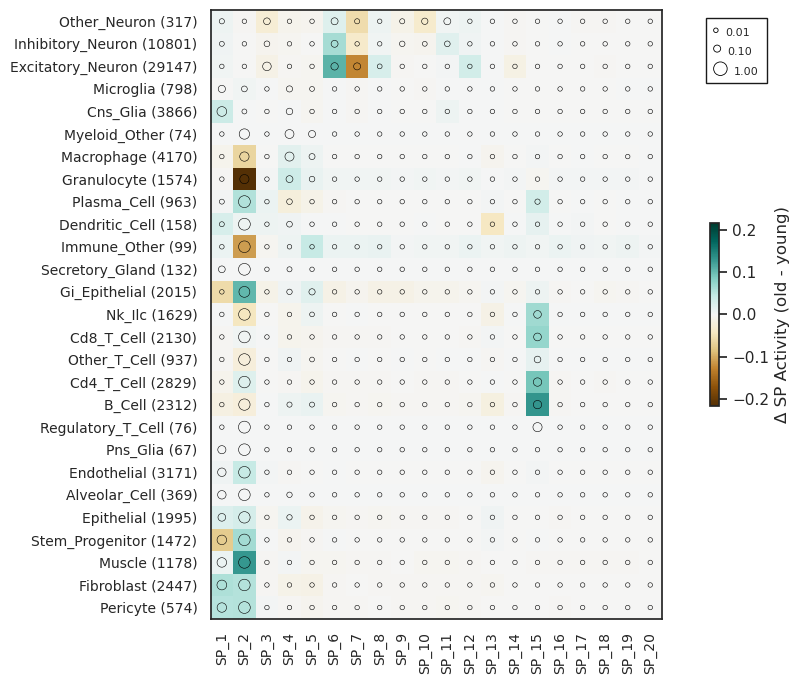

In [43]:
cell_type_col = "refined_cell_type"
fig = plot_factor_circles(splice_adata, cell_type_col=cell_type_col)
plt.savefig(f"{OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {OUTPUT_DIR}/delta_median_old_minus_young_by_{cell_type_col}_dot_heatmap.pdf")

age_group
young    479
old      319
Name: count, dtype: int64 age_numeric
54    295
43    265
50    188
57     24
40     17
46      9
Name: count, dtype: int64
0.005465460435006286


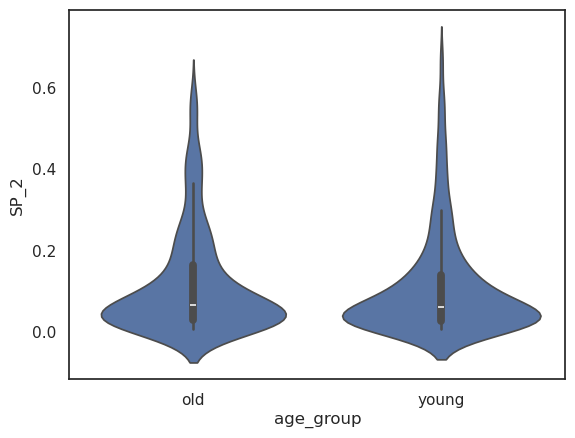

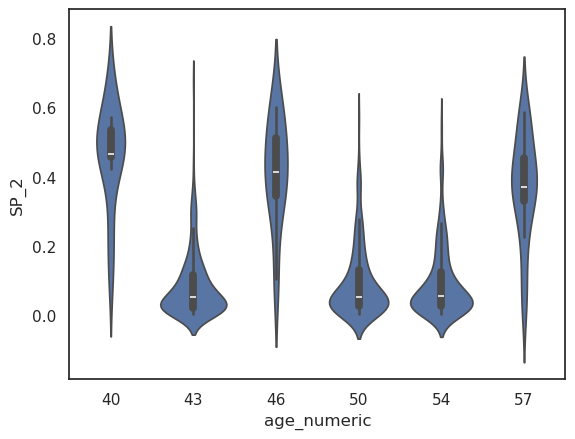

In [44]:
muscle = splice_adata.obs[splice_adata.obs["refined_cell_type"] == "Microglia"]
# print how many cells are in each age group
print(muscle["age_group"].value_counts(), muscle["age_numeric"].value_counts())
print(muscle["SP_2"].corr(muscle["age_numeric"]))
sns.violinplot(x="age_group", y="SP_2", data=muscle)
plt.show()
sns.violinplot(x="age_numeric", y="SP_2", data=muscle)
plt.show()


In [45]:
def plot_factor_junction_annotation_counts(final_df, output_path):
    """
    Create a stacked barplot showing the number of significant junctions per factor,
    colored by junction annotation category.
    """
    # Count unique junctions by (factor, annotation)
    counts = (
        final_df.groupby(["factor_idx", "junction_annotation"])["junction_id_index"]
        .nunique()
        .reset_index(name="count")
    )
    # Add factor name column
    counts["factor_name"] = "SP_" + (counts["factor_idx"] +1).astype(str)
    # Pivot to wide format: rows=factor_name, columns=annotation, values=count
    pivot_df = counts.pivot(index="factor_name", columns="junction_annotation", values="count").fillna(0)
    # print table
    print(pivot_df)
    # Sort by total number of junctions
    pivot_df["total"] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values("total", ascending=False)
    pivot_df = pivot_df.drop(columns="total")
    # Plot
    plt.figure(figsize=(5, 3))
    pivot_df.plot(
        kind="bar",
        stacked=True,
        colormap="viridis",  # Or use sns.color_palette("Set2", n_colors=...)
        edgecolor="black"
    )
    plt.xlabel("Splicing Program", fontsize=12)
    plt.ylabel("# of Significant Junctions", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="Junction Annotation", fontsize=9, title_fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    # Save
    plt.savefig(output_path, dpi=300)
    print(f"Saved to {output_path}")
    plt.show()
    plt.close()

In [46]:
def plot_junction_factor_distribution(final_df, output_path):
    """Create an improved histogram showing distribution of factors per junction"""
    # Get counts of factors/junction
    junc_counts = final_df.groupby("junction_id_index")["factor_idx"].nunique()
    junc_counts_df = pd.DataFrame({"junction_id_index": junc_counts.index, "num_factors": junc_counts.values})
    # Create figure with appropriate size
    plt.figure(figsize=(5, 4))
    # Create histogram with better styling
    ax = sns.histplot(junc_counts_df["num_factors"], bins=range(1, junc_counts_df["num_factors"].max() + 2), 
                     kde=True, color='steelblue', edgecolor='darkblue', alpha=0.7)
    # Add mean line
    mean_factors = junc_counts_df["num_factors"].mean()
    plt.axvline(mean_factors, color='red', linestyle='--', linewidth=2)
    plt.text(mean_factors + 0.2, plt.ylim()[1]*0.9, f'Mean: {mean_factors:.2f}', 
             color='red', fontweight='bold')
    # Add title and labels with better formatting
    plt.xlabel("# of Splicing Programs with Significant \nEffect on Junction", fontsize=12)
    plt.ylabel("# of junctions", fontsize=12)
    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3)
    # increase tick font size 
    # Adjust layout
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    # Save figure with higher DPI
    plt.savefig(output_path, dpi=300)
    print(f"Saved to {output_path}")
    plt.show()
    plt.close()

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/differential_splicing_barplot.pdf


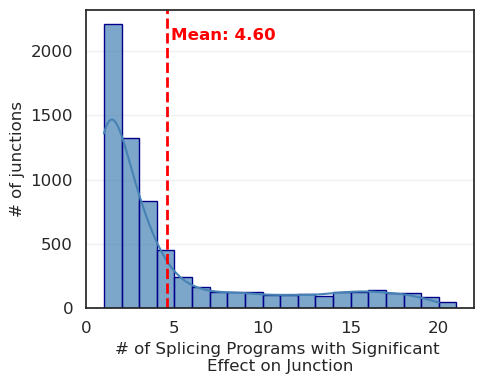

In [47]:
plot_junction_factor_distribution(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_barplot.pdf"))

junction_annotation  3_prime_annotated  5_prime_annotated  Both_SS_annotated  \
factor_name                                                                    
SP_1                              94.0               72.0             1664.0   
SP_10                             57.0               32.0              995.0   
SP_11                             52.0               31.0              985.0   
SP_12                             69.0               54.0             1897.0   
SP_13                             77.0               66.0             1519.0   
SP_14                             83.0               64.0             1300.0   
SP_15                             87.0               87.0             1950.0   
SP_16                             48.0               26.0              843.0   
SP_17                             55.0               34.0              840.0   
SP_18                             53.0               31.0              850.0   
SP_19                             29.0  

<Figure size 500x300 with 0 Axes>

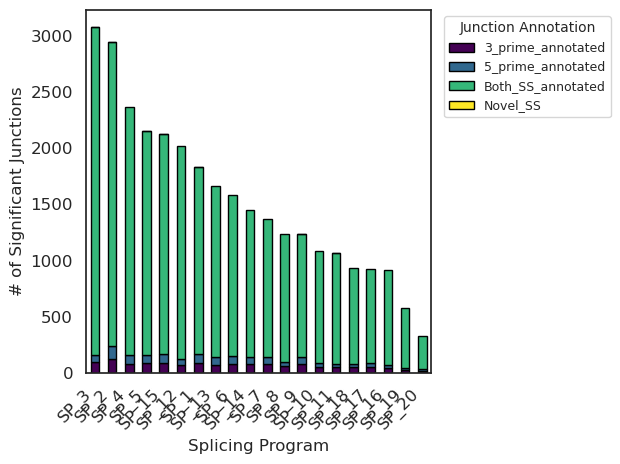

In [48]:
plot_factor_junction_annotation_counts(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_annotation_type_barplot.pdf"))

## Recalculate differential splicing junctions

In [49]:
# Reset junction_id_index column 
psi_samples = leaflet_model["psi_samples"]
splice_adata.var["junction_id_index"] = np.arange(splice_adata.n_vars)
print("\n>> Running analysis functions...")
results = ds.analyze_all_factors_psi(psi_samples, top_junctions=splice_adata.var["junction_id_index"].values, min_effect_size=0.2)
all_results = []

for factor_idx, (effect_size_list, significance_df) in results.items():
    # Append to list
    all_results.append(significance_df)
    print("\n>> Running analysis functions...")

# Concatenate all results into a single DataFrame
final_df = pd.concat(all_results, ignore_index=True)
final_df["junction_id_index"] = final_df["junction_idx"]
# convert splice_adata.var["junction_id_index"] to dtype int64
splice_adata.var["junction_id_index"] = splice_adata.var["junction_id_index"].astype("int64")



>> Running analysis functions...
Analyzing differential splicing for 20 factors...
Finding DS junctions in factor 0 vs. all others


100%|██████████| 19486/19486 [00:03<00:00, 5620.80it/s]


Found 3073 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 1 vs. all others


100%|██████████| 19486/19486 [00:03<00:00, 5693.49it/s]


Found 2945 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 2 vs. all others


...

Found 932 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 18 vs. all others


100%|██████████| 19486/19486 [00:03<00:00, 5666.72it/s]


Found 328 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 19 vs. all others


100%|██████████| 19486/19486 [00:03<00:00, 5693.99it/s]


Found 929 significant junctions with effect size > 0.2 at FDR < 0.05

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...


In [50]:
# Step 2: Rename and map
final_df = final_df.rename(columns={"factor_idx": "old_factor_idx"})
final_df["factor_idx"] = final_df["old_factor_idx"].map(old_to_new_factor_idx)

In [51]:
# Merge with adata.var using junction_id_index
final_df = final_df.merge(splice_adata.var, on="junction_id_index")

In [52]:
final_df.iloc[1]

old_factor_idx                                                           0
junction_idx                                                             1
effect_size                                                      -0.003928
abs_effect_size                                                   0.003928
effect_size_var                                                   0.000049
num_greater                                                            0.0
prob_greater                                                           0.0
prob_lessoreq                                                          1.0
significant                                                          False
delta                                                                  0.2
psi_factor_mean                                                   0.000435
psi_nonfactor_mean                                                0.004363
fdr_curve                                                         0.827308
n_significant            

In [53]:
# Create boolean masks for gene types
is_aging_gene = final_df["gene_name"].isin(aging_genes_mouse)
is_rbp_gene = final_df["gene_name"].isin(rbps)

# Initialize junction_label with 'Other'
final_df["junction_label"] = "Other"
final_df.loc[is_rbp_gene, "junction_label"] = "RBP"
final_df.loc[is_aging_gene, "junction_label"] = "Aging"

# Set 'Aging+RBP' if it's both (this will overwrite 'Aging' or 'RBP' if applicable)
final_df.loc[is_aging_gene & is_rbp_gene, "junction_label"] = "Aging+RBP"
print(final_df.junction_label.value_counts())

junction_label
Other    367060
RBP       22660
Name: count, dtype: int64


In [54]:
final_df = final_df.merge(atse_df, on="junction_id")

In [55]:
splice_adata.var[splice_adata.var["gene_name"] == "MYL6"]

,junction_id,event_id,splice_motif,annotation_status,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,clean_gene_id,...,mean_counts_per_cell,junction_variability,annotation_status_score,expression_breadth_score,read_count_score,variability_score,conservation_score,junction_id_index,RBP_gene,Aging_gene
2634,chr12_56160320_56160625_+,ENSG00000092841.19_atse_4,GT-AG,both,ENSG00000092841,3,0.0,1.0,5161850,ENSG00000092841,...,115.849686,0.519879,0.5,3.335366,14.675780,1.0,1.0,2634,False,False
2635,chr12_56160320_56161386_+,ENSG00000092841.19_atse_4,GT-AG,both,ENSG00000092841,3,0.0,1.0,7489129,ENSG00000092841,...,107.657594,0.190981,0.5,3.877740,15.160152,0.5,1.0,2635,False,False
2636,chr12_56160670_56161386_+,ENSG00000092841.19_atse_4,GT-AG,both,ENSG00000092841,3,0.0,1.0,4637767,ENSG00000092841,...,102.094932,0.600988,0.5,3.361905,14.576895,1.0,1.0,2636,False,False


Unique transcripts: ['ENST00000293422.9', 'ENST00000348108.8', 'ENST00000547408.5', 'ENST00000547649.5', 'ENST00000548293.5', 'ENST00000548400.5', 'ENST00000548580.5', 'ENST00000549017.5', 'ENST00000549566.5', 'ENST00000550697.6']
Unique transcripts to remove: ['s-1070712502957640869:e-391529944873553102', 's-129312642148515906:e-8636421683829168051', 's-1519386370360924338:e-3332650847804666328', 's-1519386370360924338:e-8765401075596503536', 's-1519386370360924338:e1141604793335427595', 's-1519386370360924338:e5191924286077489188', 's-1519386370363584544:e-3332650847804666328', 's-1563920079470052154:e1257888955262701096', 's-2324364779756209311:e-3454057902898627273', 's-2324364779756209311:e-391529944856601506', 's-2324364779756209311:e-391529944879203634', 's-2324364779756209311:e-391540111956300783', 's-2324364779756209311:e-7589057708309282275', 's-2324364779756209311:e6011781178891919844', 's-2324364779756209311:e6966050254279743752', 's-2324364779759034577:e-391529944873553102

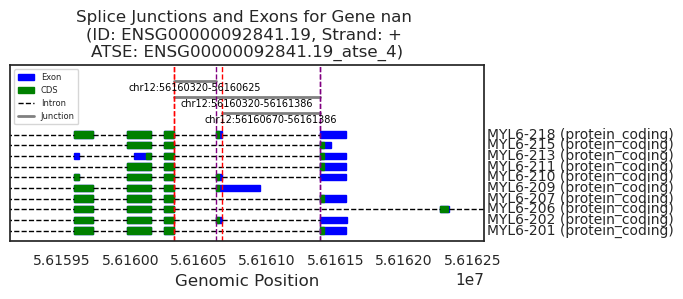

ATSE visualization saved: mouse_ENSG00000092841.19_atse_4.pdf


{'junctions':                        event_id             gene_id  gene_name  gene_types  \
 9204  ENSG00000092841.19_atse_4  ENSG00000092841.19        NaN         NaN   
 9205  ENSG00000092841.19_atse_4  ENSG00000092841.19        NaN         NaN   
 9206  ENSG00000092841.19_atse_4  ENSG00000092841.19        NaN         NaN   
 
       num_junctions event_type chromosome strand  atse_start  atse_end  ...  \
 9204              3    complex      chr12      +    56160320  56161386  ...   
 9205              3    complex      chr12      +    56160320  56161386  ...   
 9206              3    complex      chr12      +    56160320  56161386  ...   
 
       donor_total_reads  acceptor_total_reads  splice_motif  donor_seq  \
 9204           12129310               4637900         GT-AG         GT   
 9205           12675956              12129310         GT-AG         GT   
 9206           12675956               5163000         GT-AG         GT   
 
       acceptor_seq  position_off_5_prime pos

In [56]:
mouse_event = "ENSG00000092841.19_atse_4"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_human,
                 species="mouse", base_width=7, 
                       trans_height=0.2, 
                  padding=200, show_junc_lines=True)

In [57]:
# save final_df to csv 
final_df.to_csv(f"{OUTPUT_DIR}/final_df.tsv.gz", index=False, sep="\t", compression="gzip")
print(f"Saved final_df to {OUTPUT_DIR}/final_df.tsv.gz")

Saved final_df to /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/model_train/HUMAN_FOUNDATION/results/2025-07-31/2025-08-01/param_id_1/analysis_outputs/final_df.tsv.gz
